# Figure showing path-independence of CMIP6 SSP runs

Figure showing how regionally aggregated summary statistics are not dependent on the SSP at a given GWL. 

Also calculating location-by-location Kolmogorov-Smirnov tests, pairwise by experiment within a given model, against a null that, for a given model, the (summary statistics of the) runs from different SSPs are drawn from the same distribution. 

In [203]:
import xarray as xr
import xagg as xa
import numpy as np
import pandas as pd
import geopandas as gpd
from scipy import stats as sstats
import re
import glob
import os
import string
from matplotlib import pyplot as plt
from matplotlib import patches as mpatches
from cartopy import crs as ccrs
import cmocean
from tqdm.notebook import tqdm
import warnings

import arraylake
import zarr

from distributed import Client

from funcs_support import get_params,get_filepaths, utility_save, utility_print
from funcs_aux import get_landmask
dir_list = get_params()

In [ ]:
client = Client()
display(client)

In [77]:
# Get WG1 regions, if not present
poly_fn = f'{dir_list['aux']}geo_data/IPCC-WGI-reference-regions-v4.shp'
if not os.path.exists(poly_fn):
    os.system('wget https://github.com/IPCC-WG1/Atlas/raw/refs/heads/main/reference-regions/IPCC-WGI-reference-regions-v4_shapefile.zip '+
              f'-P {dir_list['aux']}')
    os.system(f'unzip {dir_list['aux']}IPCC-WGI-reference-regions-v4_shapefile.zip -d {dir_list['aux']}geo_data/')
    os.system(f'rm -rf {dir_list['aux']}IPCC-WGI-reference-regions-v4_shapefile.zip')

# Read in WG1 regions shapefile
gdf = gpd.read_file(poly_fn)
# Remove fully ocean regions and east/west antarctica
gdf = gdf.query('Type != "Ocean" and Acronym != "EAN" and Acronym != "WAN"') 

In [197]:
var = 'tas'
gwl = 2

## Load BCD-ME data

In [198]:
# Start ArrayLake client
al_client = arraylake.Client()

# Start session to access 1-deg bias-corrected data
repo = al_client.get_repo("ClimateUncertaintyLab/bcd_me_qdm")
session = repo.readonly_session(branch="main")

# Get list of available models
modlist = list(zarr.open_group(session.store,mode='r').group_keys())

In [199]:
# Get landmask for uniform 1-deg data
ds_grid = xr.open_zarr(session.store, zarr_format=3, group=modlist[0])[['lat','lon']]
landmask = get_landmask(ds_grid)

lat/lon bounds not found in dataset; they will be created.


In [200]:
# Get which models / runs have data
has_data_all = [xr.open_zarr(session.store, zarr_format=3, group=mod)
                for mod in modlist]
has_data_all = [hd.has_data for hd in has_data_all if 'has_data' in hd ]
has_data_all = xr.concat(has_data_all,dim='idv',join='outer').load()
has_data_all = has_data_all.where(~np.isnan(has_data_all),0)

In [201]:
# Figure out maximum number of runs that would allow the same number
# of runs across experiments (and models) 
min_data_across_exps = has_data_all.sel(gwl=2).groupby(['model','experiment']).sum().min('experiment',skipna=False).dropna('model')
min_data_across_exps

<xarray.DataArray 'has_data' (variable: 2, model: 9)> Size: 144B
array([[ 2.,  6., 15.,  4.,  3.,  3.,  3., 10.,  1.],
       [ 0.,  1.,  0.,  0.,  0.,  0.,  3., 10.,  5.]])
Coordinates:
  * variable  (variable) object 16B 'tas' 'tasmax'
  * model     (model) object 72B 'CESM2-WACCM' 'CNRM-CM6-1' ... 'MRI-ESM2-0'
    gwl       float64 8B 2.0

In [110]:
has_data_tmp = has_data_all.sel(gwl=2,variable=var)
has_data_tmp = has_data_tmp.where(has_data_tmp,drop=True)
has_data_tmp = has_data_tmp.set_index(idv = ['model','experiment','run']).to_dataframe().reset_index()
has_data_tmp = (has_data_tmp.set_index(['model']).join(min_data_across_exps.sel(variable=var).to_dataframe()[['has_data']].
                                                       rename({'has_data':'nruns'},axis=1)).reset_index())
has_data_tmp = has_data_tmp.drop(['variable','gwl','has_data','has_data'],axis=1)

has_data_subset = (
    has_data_tmp.assign(
        rank=has_data_tmp.groupby(['model','experiment']).cumcount()
    )
    .query("rank < nruns")
)

# Keys to process
keys_all = has_data_subset.set_index(['model','experiment','run']).index

In [148]:
modlist_tmp = keys_all.levels[0]

dss = []

for mod in modlist_tmp:
    print(f'Processing {mod}...')
    # Extract the needed locations, for GWLs 0.61 and 2 and one proj_base
    ds_tmp = (xr.open_zarr(bcd_fns.loc[('qdm',mod),'path']).set_index(idv = ['model','experiment','run']).sel(idv = keys_all[keys_all.get_loc(mod)],
                                                                                                 gwl = [0.61,gwl],
                                                                                                 proj_base = 'ERA5'))
    ds_tmp = ds_tmp[[var]]

    # Subset to land only
    ds_tmp = ds_tmp.where(landmask)

    # Calculate mean, std, max for figure
    ds_tmp = xr.merge([ds_tmp.mean(('dayofyear','year'),skipna=False).rename({var:var+'mean'}),
                                       ds_tmp.std(('dayofyear','year'),skipna=False).rename({var:var+'std'}),
                                       ds_tmp.max(('dayofyear','year'),skipna=False).rename({var:var+'max'})])

    # Add to list
    dss.append(ds_tmp.load())

Processing CESM2-WACCM...
Processing CNRM-CM6-1...
Processing CanESM5...
Processing EC-Earth3-Veg...
Processing FGOALS-g3...
Processing IPSL-CM6A-LR...


/glade/derecho/scratch/schwarzwald/tmp/ipykernel_103868/3868837545.py:8: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  ds_tmp = (xr.open_zarr(bcd_fns.loc[('qdm',mod),'path']).set_index(idv = ['model','experiment','run']).sel(idv = keys_all[keys_all.get_loc(mod)],
/glade/u/home/schwarzwald/.conda/envs/bcd_me/lib/python3.13/site-packages/zarr/core/group.py:3535: ZarrUserWarning: Object at .done_diag is not recognized as a component of a Zarr hierarchy.
  warnings.warn(


Processing MIROC6...
Processing MPI-ESM1-2-LR...
Processing MRI-ESM2-0...


In [154]:
# Make into single dataset
dss = xr.concat(dss,dim='idv')

# Get change to desired GWL
ddss = dss.sel(gwl=gwl) - dss.sel(gwl=0.61)

# Aggregate to IPCC regions
wm = xa.pixel_overlaps(dss,gdf)
with xa.set_options(impl='numba'):
    agg = xa.aggregate(ddss,wm)
ddss_out = agg.to_dataset()

# Put back in metadata coords lost by xagg
for v in ['model','experiment','run']:
    ddss_out = ddss_out.assign_coords({v:(('idv'),ddss[v].values)})

# Get number of runs
nruns = int(ddss_out.sizes['idv'] / 3)
nmods = len(np.unique(ddss['model'].values))

# Make experiment its own dimension
ddss_out = ddss_out.set_index(idv = ['model','experiment','run']).unstack()
ddss_out = ddss_out.stack(idv = ['model','run']).dropna('idv',how='all')

## Regionally aggregated diagnostic figure

/glade/u/home/schwarzwald/projects/bcd_me_final/figures/ssp_dependence_by_gwl.pdf saved!
/glade/u/home/schwarzwald/projects/bcd_me_final/figures/ssp_dependence_by_gwl.png saved!


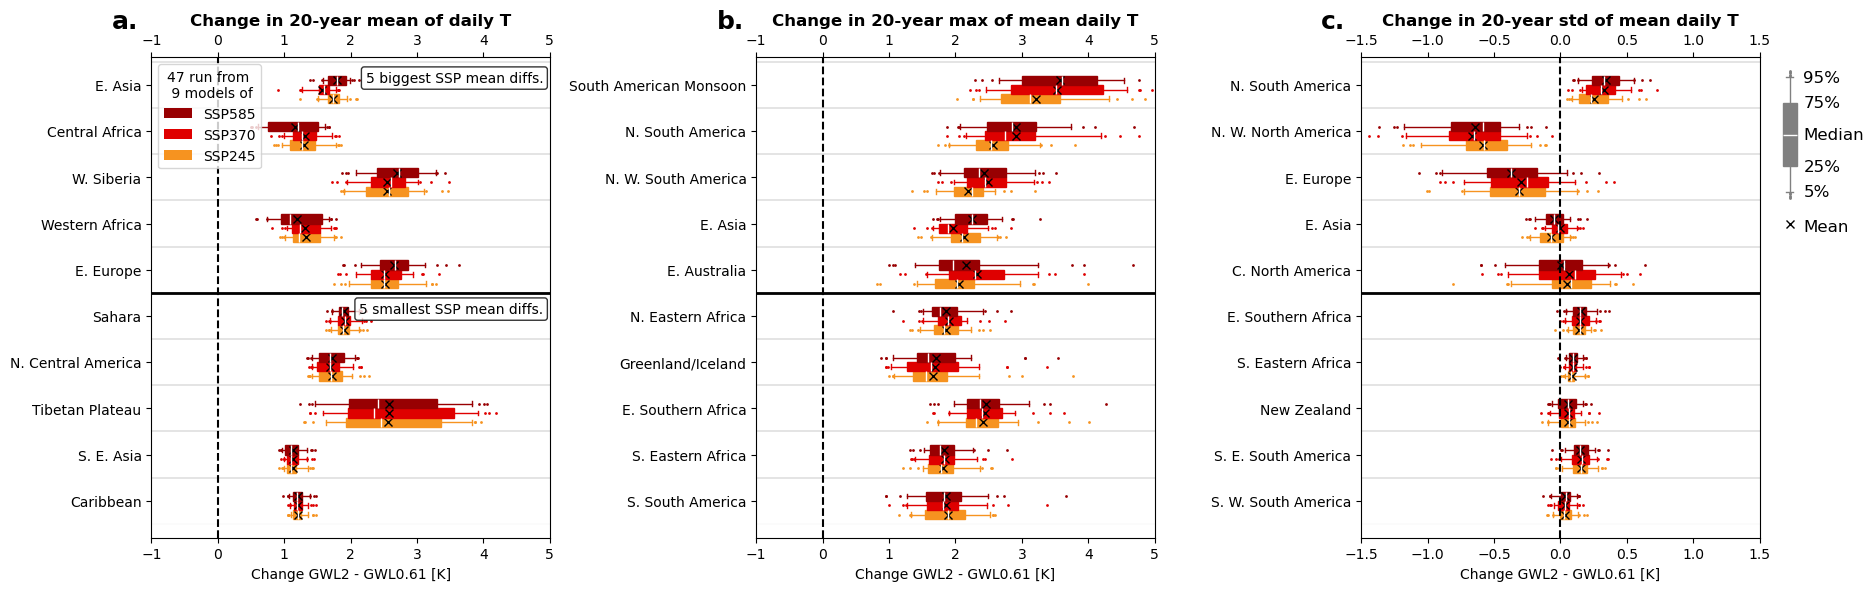

In [213]:
#-------------------------------------------------------------
#- Create regionally aggregated diagnostic figure
#-------------------------------------------------------------

save_fig = True
output_fn = dir_list['figs']+'ssp_dependence_by_gwl'


#var = 'tasmean'
varlist = ['tasmean','tasmax','tasstd']

# OPTION: only show regions where means are statistically distinguishable 

# from https://pyam-iamc.readthedocs.io/en/stable/tutorials/ipcc_colors.html
colors = {'ssp119':'#00a9cf',
          'ssp126':'#003466',
          'ssp245':'#f69320',
          'ssp370':'#df0000',
          'ssp3-LowNTCF':'e61d25',
          'ssp434':'#2274ae',
          'ssp460':'#b0724e',
          'ssp534-OS':'#92397a',
          'ssp585':'#980002'}

metric_names = {'tasmean':{'description':'20-year mean of daily T','units':'K','xlims':[-1,5]},
                'tasmax':{'description':'20-year max of mean daily T','units':'K','xlims':[-1,5]},
                'tasstd':{'description':'20-year std of mean daily T','units':'K','xlims':[-1.5,1.5]}}


barwidths = 0.2

show_top_x = 5
#sort_type = 'biggest_diff' # least_diff
sort_type = 'both'

fig = plt.figure(figsize=(20,6))

run_number_desc = f'{str(nruns)} run from\n {str(nmods)} models'

gs = plt.GridSpec(nrows=1,ncols=4,width_ratios = [*([1]*len(varlist)),0.035])

for var_idx,var in enumerate(varlist):
    
    
    plot_data = ddss_out[var]
    
    #-------- Sort regions from biggest differences between exps to least --------
    diffs = []
    diff_labels = []
    for exp1 in plot_data.experiment.values:
        for exp2 in plot_data.experiment.values:
            diffs.append(np.abs(plot_data.sel(experiment=exp1).mean(['idv']) - plot_data.sel(experiment=exp2).mean(['idv'])).drop_vars('experiment',errors='ignore'))
            diff_labels.append(exp1+'-'+exp2)
    diffs = xr.concat(diffs,dim=pd.Index(diff_labels,name='diffexps'))
    
    if sort_type in ['both','biggest_diff']:
        diffs_sorted = diffs.max('diffexps').sortby(diffs.max('diffexps'),ascending=False)
    else:
        diffs_sorted = diffs.max('diffexps').sortby(diffs.max('diffexps'),ascending=True)
    diffs_sorted = diffs_sorted.dropna('poly_idx')
    
    #-------- Plot figure --------
    
    ax = fig.add_subplot(gs[var_idx])
    
    
    if sort_type == 'both':
        poly_locs = np.r_[diffs_sorted.poly_idx.values[:show_top_x],
                          diffs_sorted.poly_idx.values[-show_top_x:]][::-1]
    else:
        poly_locs = diffs_sorted.poly_idx.values[:show_top_x]
    
    ax.axhline(-0.5,color='grey',linewidth=0.2,alpha=0.2)
    for reg,reg_idx in zip(poly_locs,range(len(poly_locs))): #range(diffs_sorted.sizes['poly_idx'])
        for exp,exp_idx in zip(plot_data.experiment.values,range(plot_data.sizes['experiment'])):
            # np.boxplot can't handle NaNs
            plot_data_tmp = plot_data.sel(experiment=exp,poly_idx=reg)
            plot_data_tmp = plot_data_tmp[~np.isnan(plot_data_tmp)]
    
            # relative to percent
            #plot_data_tmp = plot_data_tmp*100
            
            bplot = plt.boxplot(plot_data_tmp,
                                positions=[reg_idx-(1.5*barwidths)+barwidths*exp_idx],patch_artist=True,widths=barwidths,
                                whis=[5,95],flierprops = {'marker':'.','markersize':2},vert=False)
        
            # Set colors of boxplots
            for item in ['boxes', 'whiskers', 'fliers', 'caps']:
                plt.setp(bplot[item],color=colors[exp])
            plt.setp(bplot['medians'],color='white')
            plt.setp(bplot['fliers'],markeredgecolor=colors[exp])
    
            # plot means
            plt.plot([plot_data_tmp.mean()],
                     [reg_idx-(1.5*barwidths)+barwidths*exp_idx],
                     '-x',color='k')
    
        ax.axhline(reg_idx+0.5,color='grey',linewidth=0.3)
    
    ax.axvline(0,color='k',linestyle='--')
    
    # Set tickmarks
    ax.set_yticks(range(len(poly_locs)), #range(diffs_sorted.sizes['poly_idx'])
                  labels=[re.sub(r'\&',' & ',
                                 re.sub(r'\.','. ',
                                 re.sub(r'\-',' ',t)))
                          for t in ddss_out.Name.sel(poly_idx = poly_locs).values])
                          
    
    ax.tick_params(axis='x',labeltop=True,top=True)
    ax.set_xlim(metric_names[var]['xlims'])
    
    # If showing top n _and_ bottom n, create a barrier between them
    if sort_type == 'both':
        ax.axhline(show_top_x-1+0.5,color='k',linewidth=2)

        if var_idx == 0:
            # And label the two halves
            xmax = ax.get_xlim()[1]   # rightmost x in data units
            for text,y_top in zip([f'{str(show_top_x)} biggest SSP mean diffs.',
                               f'{str(show_top_x)} smallest SSP mean diffs.'],
                              [show_top_x*2 - 1 - 0.2,
                               show_top_x - 1 - 0.2]):
                ax.text(
                    xmax-0.1, y_top+0.5, text,
                    ha='right', va='top',
                    fontsize=10,
                    bbox=dict(boxstyle="round,pad=0.3,rounding_size=0.2", 
                        fc='w',ec='k',alpha=0.8, linewidth=1.0
                    )
                )
        
    
    
    #----- Legend
    if var_idx == 0:
        lgd = ax.legend(handles=[mpatches.Patch(facecolor=colors[exp],
                                 label=exp.upper())
                                 for exp in plot_data.experiment.values][::-1],
                        loc='upper left',
                        title = run_number_desc+' of')

    #----- Title
    
    title_str = f'Change in {metric_names[var]['description']}'
    #if sort_type == 'biggest_diff':
    #    title_str = title_str+'\n('+str(show_top_x)+' regions with largest inter-SSP differences)'
    #else:
    #    title_str = title_str+'\n('+str(show_top_x)+' regions with smallest inter-SSP differences)'
    #title_str = title_str+'\n'+run_number_desc
    ax.set_title(title_str,fontweight='bold')
    
    ax.set_xlabel(f'Change GWL{str(gwl)} - GWL0.61 [{metric_names[var]['units']}]')

    #----- Subplot lettering
    ax.text(
        -0.1, 1.1, string.ascii_lowercase[var_idx]+'.',             
        transform=ax.transAxes,ha='left', va='top',
        fontsize=18,fontweight='bold',
    )

plt.tight_layout()

#----- Add reference legend boxplot
bbox = ax.get_position()
ax = fig.add_axes([bbox.x0+0.9*bbox.width, bbox.y0+bbox.height-0.01-bbox.height*0.35, bbox.width*0.35, bbox.height*0.35])
widths = 0.05
bplot = ax.boxplot(np.arange(-50,51),
                               patch_artist=True,widths=widths,
                               whis=[5,95],flierprops = {'marker':'.','markersize':2})

# Set colors of boxplots
for item in ['boxes', 'whiskers', 'fliers', 'caps']:
    plt.setp(bplot[item],color='grey')
plt.setp(bplot['medians'],color='white')
plt.setp(bplot['fliers'],markeredgecolor='grey')

ax.plot(1,-70,'x',color='k')

for text,loc in zip([r'Mean',r'5%',r'25%','Median',r'75%',r'95%'],
                    [-72,-45,-25,0,25,45]):
    
    ax.annotate(text,xy=(1+widths/2+0.025,loc),ha='left',va='center',
                fontsize=12)
ax.set_xlim(0.75,1.25)
ax.axis('off')

if save_fig:
    utility_print(output_fn)